# Parte 1: Preparación de eltorno

In [2]:
!pip install gdown

In [3]:
# Verificar GPU en Colab
import tensorflow as tf
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

# Imports
import numpy as np
import keras
from keras import layers

# Descargar dataset
!gdown 199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN -O titulares.txt

# Cargar texto
with open('titulares.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Caracteres totales: {len(text)}")
print(f"Muestra:\n{text[:500]}")

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Downloading...
From: https://drive.google.com/uc?id=199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN
To: /content/titulares.txt
100% 60.4k/60.4k [00:00<00:00, 2.92MB/s]
Caracteres totales: 60438
Muestra:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatico sigue siendo una amenaza global
inversionistas buscan oportunidades en energias renovables
aumenta la demanda de vehiculos electricos
vacunas contra covid19 cuando estaremos todos protegidos
el debate sobre las vacunas sigue dividiendo opiniones
expertos en salud analizan la efectividad de las vacunas
vacunacion masiva contra el coronavirus en marcha
el mercado de criptomonedas se dispara a nuevas alturas
es bitcoi


# Parte 2: Tokenización a niver de carácter

In [4]:
# Crear vocabulario
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f"Vocabulario: {vocab_size} caracteres únicos")

# Mapeos
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return ''.join([idx_to_char[i] for i in ids])

# Test
print(encode("hola"))
print(decode([15, 22, 19, 8]))

Vocabulario: 33 caracteres únicos
[15, 22, 19, 8]
hola


# Parte 3, preparación de los datos de entrenamiento

In [5]:
# Parámetros
SEQ_LENGTH = 80
BATCH_SIZE = 64

# Tokenizar todo
tokens = np.array(encode(text))

# Crear secuencias X, y
def crear_secuencias(tokens, seq_len):
    X, y = [], []
    for i in range(len(tokens) - seq_len):
        X.append(tokens[i:i+seq_len])
        y.append(tokens[i+1:i+seq_len+1])
    return np.array(X), np.array(y)

X, y = crear_secuencias(tokens, SEQ_LENGTH)
print(f"Secuencias: {X.shape}")

# Dataset de TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Secuencias: (60358, 80)


# Parte 4: Componenttes del Transformer
## 4.1 Embeddings con posición

In [6]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

4.2 Bloque Transformer con Atención Causal

In [7]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def causal_attention_mask(self, batch_size, seq_len):
        """Máscara para que cada posición solo vea anteriores."""
        i = tf.range(seq_len)[:, tf.newaxis]
        j = tf.range(seq_len)
        mask = tf.cast(i >= j, dtype=tf.float32)
        mask = tf.reshape(mask, [1, 1, seq_len, seq_len])
        return tf.tile(mask, [batch_size, 1, 1, 1])

    def call(self, inputs, training):
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
        mask = self.causal_attention_mask(batch_size, seq_len)

        attn_output = self.att(inputs, inputs, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Parte 5: Modelo completo


In [8]:
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_BLOCKS = 4

def crear_modelo():
    inputs = layers.Input(shape=(SEQ_LENGTH,), dtype=tf.int32, name='input_sequence')
    # Remove training_flag as a model input. Keras will handle the training status implicitly.

    x = TokenAndPositionEmbedding(SEQ_LENGTH, vocab_size, EMBED_DIM)(inputs)
    for _ in range(NUM_BLOCKS):
        # Pass training=True during model construction. Keras will override this with the correct
        # training status (True/False) during model.fit/model.evaluate/model.predict
        x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x, training=True)
    outputs = layers.Dense(vocab_size, activation="softmax")(x)

    # The model now expects only one input (the sequence)
    return keras.Model(inputs=inputs, outputs=outputs)

model = crear_modelo()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 80, 256)        │        28,928 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80, 33)         │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,300,769 (20.22 MB)

 Trainable params: 5,300,769 (20.22 MB)

 Non-trainable params: 0 (0.00 B)

# Parte 6: Entrenamiento

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

history = model.fit(dataset, epochs=28, callbacks=callbacks)

Epoch 1/28
944/944 ━━━━━━━━━━━━━━━━━━━━ 115s 89ms/step - accuracy: 0.7255 - loss: 0.8709 - learning_rate: 0.0010
Epoch 2/28
  1/944 ━━━━━━━━━━━━━━━━━━━━ 1:57 124ms/step - accuracy: 0.6598 - loss: 1.4031

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


944/944 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.9001 - loss: 0.3100 - learning_rate: 0.0010
Epoch 3/28
944/944 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.9286 - loss: 0.2185 - learning_rate: 0.0010
Epoch 4/28
944/944 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.9367 - loss: 0.1926 - learning_rate: 0.0010
Epoch 5/28
944/944 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.9408 - loss: 0.1785 - learning_rate: 0.0010
Epoch 6/28
944/944 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.9436 - loss: 0.1695 - learning_rate: 0.0010
Epoch 7/28
944/944 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.9456 - loss: 0.1630 - learning_rate: 0.0010
Epoch 8/28
944/944 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.9472 - loss: 0.1575 - learning_rate: 0.0010
Epoch 9/28
944/944 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.9483 - loss: 0.1538 - learning_rate: 0.0010
Epoch 10/28
944/944 ━━━━━━━━━━━━━━━━━━━━ 85s 90ms/step - accuracy: 0.9496 - loss: 0.1499 - learning_rate: 0.0010
Ep

## Visualización de las curvas de entrenamiento

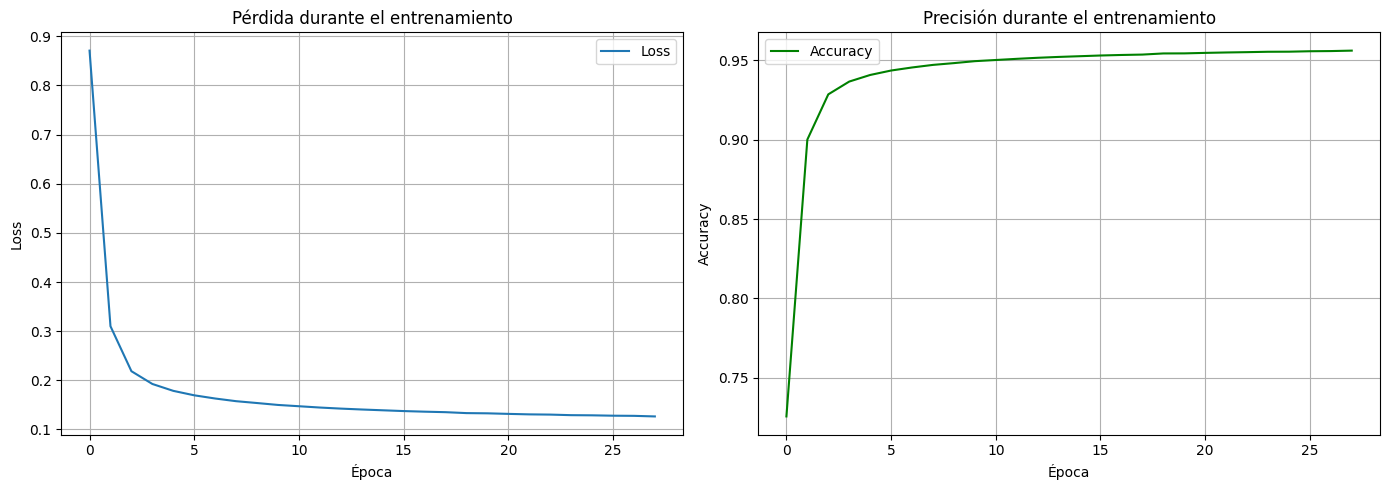

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(history.history['loss'], label='Loss')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Precisión
axes[1].plot(history.history['accuracy'], label='Accuracy', color='green')
axes[1].set_title('Precisión durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Parte 7: Generacuón del texto

In [11]:
def generar_texto(model, inicio, longitud=100, temperatura=1.0):
    """Genera texto de forma autoregresiva."""
    generado = list(encode(inicio))

    for _ in range(longitud):
        input_seq = generado[-SEQ_LENGTH:]
        input_seq = np.array(input_seq)[np.newaxis, :]

        if len(input_seq[0]) < SEQ_LENGTH:
            pad_len = SEQ_LENGTH - len(input_seq[0])
            input_seq = np.pad(input_seq, ((0,0), (pad_len, 0)))

        preds = model.predict(input_seq, verbose=0)[0, -1, :]

        preds = np.log(preds + 1e-10) / temperatura
        preds = np.exp(preds) / np.sum(np.exp(preds))

        next_idx = np.random.choice(len(preds), p=preds)
        generado.append(next_idx)

        if idx_to_char[next_idx] == '\n':
            break

    return decode(generado)

# Generar con diferentes temperaturas
print("=== Temperatura 0.5 ===")
print(generar_texto(model, "el gobierno ", temperatura=0.5))

print("\n=== Temperatura 1.0 ===")
print(generar_texto(model, "el gobierno ", temperatura=1.0))

print("\n=== Temperatura 1.5 ===")
print(generar_texto(model, "el gobierno ", temperatura=1.5))

=== Temperatura 0.5 ===
el gobierno con raacia dianana con la ansispiran a la accion y la reflexion


=== Temperatura 1.0 ===
el gobierno conses upanes que prevenir el equibrio emocionales justicia sociales y medioambientales


=== Temperatura 1.5 ===
el gobierno coqfinanidad espacia y la conservacion de los ecosistemas marinos protegiendo la vida en nuestros oc


### Experimento con diferentes inicios

In [12]:
inicios = ["la economia ", "un nuevo ", "el presidente ", "argentina ", "se espera ", "se dastapa ", "primicia "] # Se han añadido nuevos inicios a los ya propuestos

#temperatura 0.8
print("=== Temperatura 0.8 ===")
for inicio in inicios:
    print(f"Inicio: '{inicio}'")
    print(f"  → {generar_texto(model, inicio, temperatura=0.8)}")
    print()
#temperatura 0.3
print("=== Temperatura 0.3 ===")
for inicio in inicios:
    print(f"Inicio: '{inicio}'")
    print(f"  → {generar_texto(model, inicio, temperatura=0.3)}")
    print()

=== Temperatura 0.8 ===
Inicio: 'la economia '
  → la economia avais qiana esua con ciberne un mundo digitando la salud mental en un mundo agitado


Inicio: 'un nuevo '
  → un nuevo paraeas ciudades avances en que se adaptan alcanzan la reflexion


Inicio: 'el presidente '
  → el presidente biancia sia como la activismo enfrentando la atencion medica con la tecnologia avanzada


Inicio: 'argentina '
  → argentina vincia diancia de la aracia una habilidad y el bienestar emocional


Inicio: 'se espera '
  → se espera parandandnanda el futuro de la salud mental y la conservacion de los ecosistemas marinos protegiendo

Inicio: 'se dastapa '
  → se dastapa ananda esua caus autosus contre la conservacion de la biodiversidad


Inicio: 'primicia '
  → primicia dianandandandandandandanda educacion cibernetica para una navegacion segura en linea


=== Temperatura 0.3 ===
Inicio: 'la economia '
  → la economia ans anana esua consenus consus y transparente nuestrans cibernetica en la era digital p